In [1]:
# Core Libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn Theme for Visualizations
sns.set_theme()

# TensorFlow & Keras Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, mixed_precision, regularizers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, AdamW, SGD
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import (
    Input, Activation, Dense, Conv2D, MaxPooling2D, MaxPool2D, Flatten, 
    BatchNormalization, Dropout, GlobalAveragePooling2D, LeakyReLU, SpatialDropout2D
)

# Scikit-Learn for Data Splitting
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

## Datasets


### Kaggle
#### Train
##### https://www.kaggle.com/api/v1/datasets/download/omkarmanohardalvi/lungs-disease-dataset-4-types
##### https://www.kaggle.com/api/v1/datasets/download/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
##### https://www.kaggle.com/api/v1/datasets/download/tawsifurrahman/covid19-radiography-database
##### https://www.kaggle.com/api/v1/datasets/download/khanfashee/nih224folderwise-data
#### Test
##### https://www.kaggle.com/api/v1/datasets/download/unaissait/curated-chest-xray-image-dataset-for-covid19
##### https://www.kaggle.com/api/v1/datasets/download/samiulbari/pulmonary-edema-classified-by-nih

## Explore data 

In [15]:
# Specify the folder path after mounting Google Drive|
data_dir = r'E:\chest'
# List the files in the folder
classes = os.listdir(data_dir)
print(classes)

['Bacterial Pneumonia', 'Corona Virus Disease', 'Edema', 'Lung_Opacity', 'Normal', 'Tuberculosis', 'Viral Pneumonia']


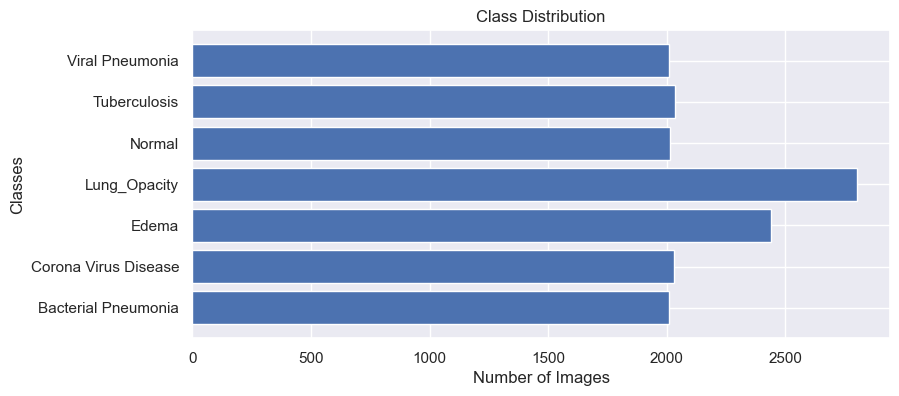

In [16]:
from collections import Counter

# Count images per class
class_counts = Counter()
for cls in classes:
    class_dir = os.path.join(data_dir, cls)
    class_counts[cls] = len(os.listdir(class_dir))

# Plot class distribution
plt.figure(figsize=(9, 4))
plt.barh(list(class_counts.keys()), list(class_counts.values()))
plt.xlabel('Number of Images')  # Number of Images should be on the x-axis
plt.ylabel('Classes')           # Classes should be on the y-axis
plt.title('Class Distribution')
plt.show()


## Building & Devolping model

In [17]:
def load_data(data_dir, classes):
    """
    Load data and create a DataFrame containing image paths and labels.
    """
    image_files, labels = [], []
    
    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f"Warning: Directory {class_dir} does not exist")
            continue
        
        files = [os.path.join(class_dir, f) for f in os.listdir(class_dir) 
                 if os.path.isfile(os.path.join(class_dir, f)) and 
                 f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]
        
        image_files.extend(files)
        labels.extend([class_name] * len(files))
    
    data_df = pd.DataFrame({'image_path': image_files, 'label': labels})
    return data_df

data_df = load_data(data_dir, classes)

In [18]:
def balance_data(data_df, balance_factor=0.01):
    """
    Balance class distribution by gradually reducing large classes instead of making them all the size of the smallest class.
    """
    print("Class distribution before balancing:")
    print(data_df['label'].value_counts())  # Print class distribution before balancing
    
    class_counts = data_df['label'].value_counts()
    min_samples, max_samples = class_counts.min(), class_counts.max()
    
    # Calculate target number of samples per class
    target_samples = int(np.clip(min_samples + balance_factor * (max_samples - min_samples), min_samples, max_samples))
    
    # Balance the data
    balanced_data = []
    for class_name in data_df['label'].unique():
        class_samples = data_df[data_df['label'] == class_name]
        sampled_data = class_samples.sample(min(len(class_samples), target_samples), random_state=42)
        balanced_data.append(sampled_data)
    
    balanced_df = pd.concat(balanced_data).sample(frac=1, random_state=42).reset_index(drop=True)

    # 🔹 Print class distribution after balancing
    print("\nClass distribution after balancing:")
    print(balanced_df['label'].value_counts())

    return balanced_df

# Execute the function
balanced_df = balance_data(data_df)

Class distribution before balancing:
label
Lung_Opacity            2800
Edema                   2440
Tuberculosis            2034
Corona Virus Disease    2031
Normal                  2013
Bacterial Pneumonia     2009
Viral Pneumonia         2008
Name: count, dtype: int64

Class distribution after balancing:
label
Lung_Opacity            2015
Tuberculosis            2015
Corona Virus Disease    2015
Edema                   2015
Normal                  2013
Bacterial Pneumonia     2009
Viral Pneumonia         2008
Name: count, dtype: int64


In [19]:
balanced_df.head()

,image_path,label
0,E:\chest\Viral Pneumonia\person77_virus_139.jpeg,Viral Pneumonia
1,E:\chest\Normal\NORMAL2-IM-0730-0001.jpeg,Normal
2,E:\chest\Lung_Opacity\Lung_Opacity-3988.png,Lung_Opacity
3,E:\chest\Tuberculosis\Tuberculosis-151.jpg,Tuberculosis
4,E:\chest\Bacterial Pneumonia\test_0_482.jpeg,Bacterial Pneumonia


In [20]:
print(balanced_df.columns)
print(balanced_df.shape)

Index(['image_path', 'label'], dtype='object')
(14090, 2)


In [21]:
balanced_df.duplicated().sum()

0

In [22]:
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14090 entries, 0 to 14089
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  14090 non-null  object
 1   label       14090 non-null  object
dtypes: object(2)
memory usage: 220.3+ KB


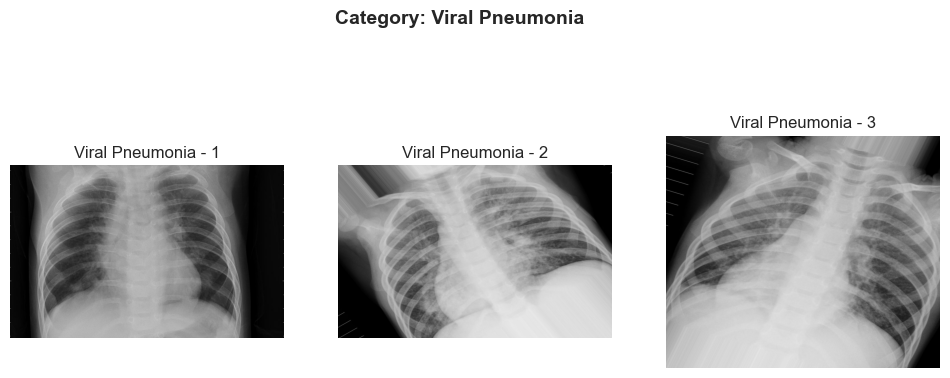

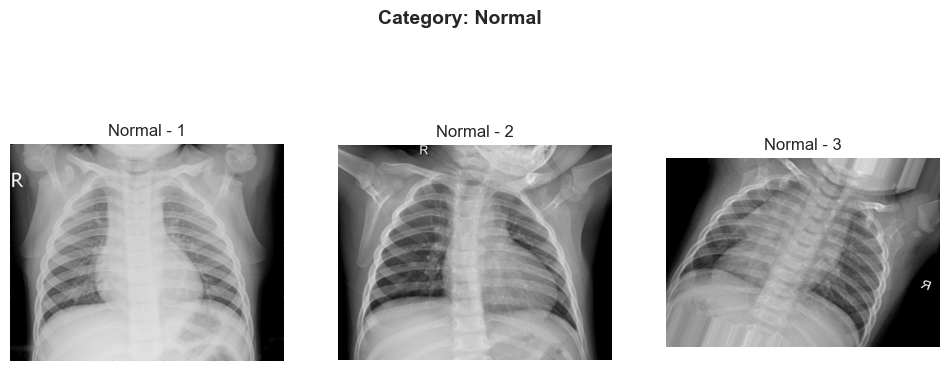

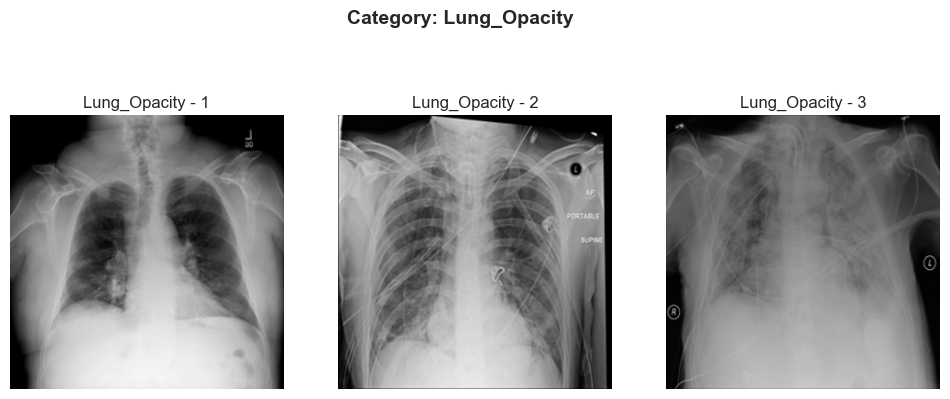

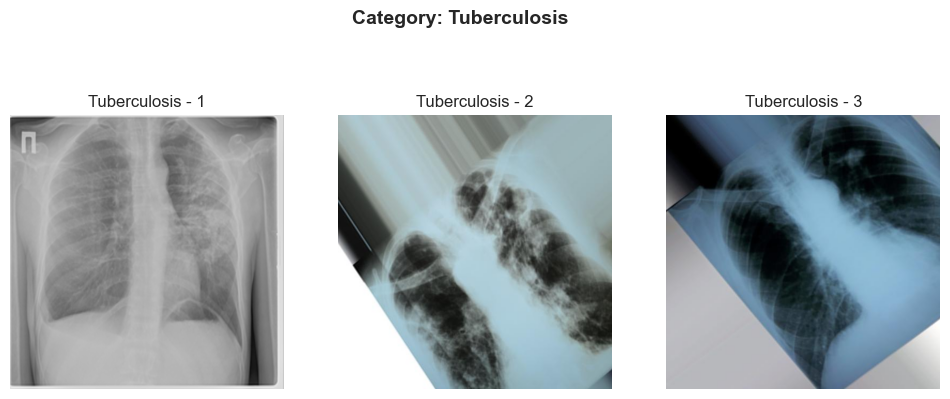

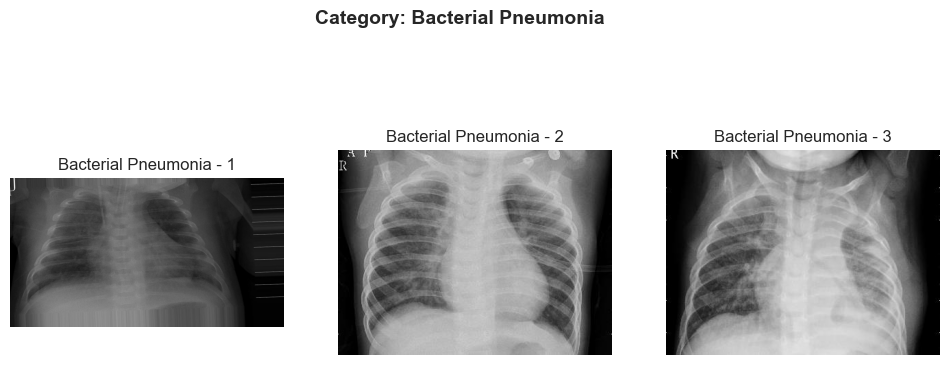

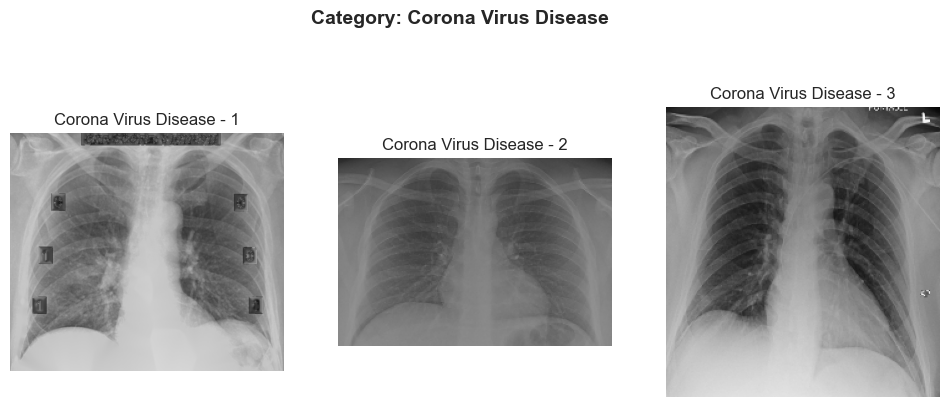

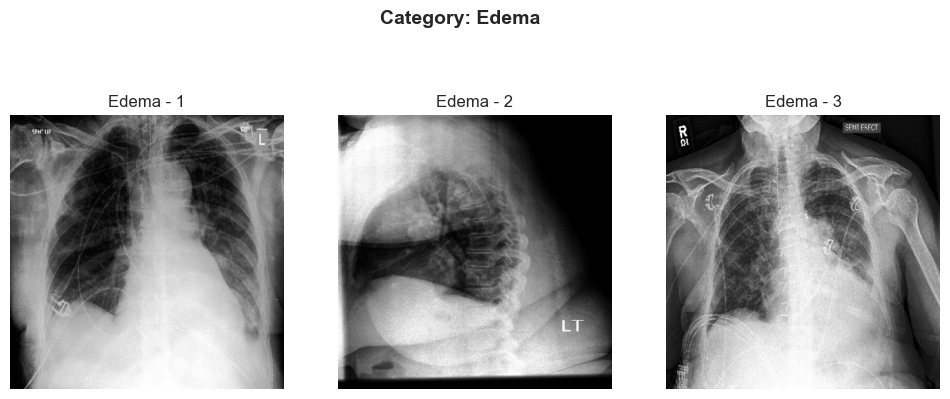

In [23]:
num_images = 3  # Number of images per category
categories = balanced_df['label'].unique()  # Get all unique categories

for category in categories:
    # Select 3 random images for the category
    category_images = balanced_df[balanced_df['label'] == category]['image_path'].iloc[:num_images]
    
    plt.figure(figsize=(12, 5))  # Create a new figure for each category
    
    for j, img_path in enumerate(category_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        
        plt.subplot(1, num_images, j + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{category} - {j+1}")
    
    plt.suptitle(f"Category: {category}", fontsize=14, fontweight='bold')  # Title for the figure
    plt.show()  # Display the figure

In [24]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler

# Encode labels
label_encoder = LabelEncoder()
balanced_df['category_encoded'] = label_encoder.fit_transform(balanced_df['label'])
balanced_df['category_encoded'] = balanced_df['category_encoded'].astype(str)

In [25]:
# Split dataset into train, validation, and test sets
train_df_new, temp_df_new = train_test_split(
    balanced_df,
    test_size=0.2,  # 80% for temp (validation + test)
    shuffle=True,
    random_state=42,
    stratify=balanced_df['category_encoded']
)

valid_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.5,  # Split temp into equal halves for validation and test
    shuffle=True,
    random_state=42,
    stratify=temp_df_new['category_encoded']
)

# Image size and shape
img_size = (224, 224)
channels = 3  # Adjust if using grayscale images
img_shape = (img_size[0], img_size[1], channels)

In [26]:
def enhance_medical_image(image, disease_type=None, img_size=(224, 224)):
    """
    Enhances medical chest X-ray images based on disease type with soft processing.
    
    Parameters:
    image (numpy.ndarray): Input image.
    disease_type (str): Type of disease to optimize for.
    img_size (tuple): Target image size (height, width).
    
    Returns:
    numpy.ndarray: Enhanced image.
    """
    # Check if image is RGB
    is_rgb = (len(image.shape) == 3 and image.shape[2] == 3)

    # Convert to grayscale if needed
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if is_rgb else image.copy()
    
    # Resize image
    resized = cv2.resize(gray, img_size).astype(np.uint8)

    # Basic contrast enhancement using CLAHE
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))  # softer clipLimit
    enhanced = clahe.apply(resized)

    # Denoising (mild)
    denoised = cv2.fastNlMeansDenoising(enhanced, None, h=5, templateWindowSize=7, searchWindowSize=21)

    # Light disease-specific enhancements
    if disease_type == 'Edema':
        blurred = cv2.GaussianBlur(denoised, (3, 3), 0)
        enhanced = cv2.addWeighted(denoised, 1.2, blurred, -0.2, 0)

    elif disease_type == 'Lung_Opacity':
        enhanced = cv2.convertScaleAbs(denoised, alpha=1.1, beta=3)

    elif disease_type == 'Tuberculosis':
        # Less aggressive sharpening
        kernel = np.array([[0, -1, 0], [-1, 5.5, -1], [0, -1, 0]])
        enhanced = cv2.filter2D(denoised, -1, kernel)

    elif disease_type == 'Corona_Virus_Disease':
        enhanced = cv2.bilateralFilter(denoised, d=7, sigmaColor=50, sigmaSpace=50)

    elif disease_type == 'Bacterial_Pneumonia':
        kernel = np.ones((2, 2), np.uint8)
        enhanced = cv2.morphologyEx(denoised, cv2.MORPH_CLOSE, kernel)
        enhanced = cv2.convertScaleAbs(enhanced, alpha=1.05, beta=5)

    elif disease_type == 'Viral_Pneumonia':
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
        enhanced = cv2.filter2D(denoised, -1, kernel)

    else:
        # Normal or unknown: just return denoised or histogram equalized
        enhanced = denoised.copy()

    # Normalize output to 0-255
    enhanced = cv2.normalize(enhanced, None, 0, 255, cv2.NORM_MINMAX)

    # Return to RGB if needed
    if is_rgb:
        enhanced = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

    return enhanced


In [27]:
def preprocess_image(img):
    img = enhance_medical_image(img, disease_type=None, img_size=img_size) 
    img = img.astype(np.float32) / 255.0 
    return img

In [28]:
# Data generators
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_image
)

ts_gen = ImageDataGenerator(
    preprocessing_function=preprocess_image
)

# Training generator
train_generator = train_gen.flow_from_dataframe(
    dataframe=train_df_new,
    x_col='image_path',  # Ensure this column contains valid image paths
    y_col='category_encoded',  # This should be either string or numeric
    target_size=img_size,
    batch_size=32,
    class_mode='sparse',  # Use 'sparse' if category_encoded is numeric
    color_mode='rgb',
    shuffle=True
)

# Validation generator
valid_generator = ts_gen.flow_from_dataframe(
    dataframe=valid_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    batch_size=32,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True
)

# Test generator
test_generator = ts_gen.flow_from_dataframe(
    dataframe=test_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    batch_size=32,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=False
)

Found 11272 validated image filenames belonging to 7 classes.
Found 1409 validated image filenames belonging to 7 classes.
Found 1409 validated image filenames belonging to 7 classes.


In [29]:
print("Class indices:", train_generator.class_indices)

Class indices: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6}


## Model

In [17]:
from tensorflow.keras.applications import DenseNet121

# Base Model Configuration
base_model = DenseNet121(weights='imagenet',
                        include_top=False,
                        input_shape=(224, 224, 3))


# Build Model
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='mish', kernel_regularizer=l2(0.0001))(x)
x = Dropout(0.4)(x)
output = Dense(7, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

optimizer = AdamW(learning_rate=0.0001)

# Model Compilation
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,169,607 (27.35 MB)

 Trainable params: 7,085,959 (27.03 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

def calculate_class_weights(dataframe):
    # تحويل الفئات إلى أعداد صحيحة إذا لم تكن كذلك
    dataframe['category_encoded'] = dataframe['category_encoded'].astype(int)

    # استخراج الفئات الفعلية الموجودة في البيانات
    unique_classes = np.unique(dataframe['category_encoded'])

    # حساب أوزان الفئات
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=unique_classes,  # استخدم الفئات الفعلية الموجودة في y
        y=dataframe['category_encoded']
    )

    # تحويل إلى قاموس
    return {int(i): float(weight) for i, weight in zip(unique_classes, class_weights)}

# إعادة حساب أوزان الفئات بعد تحويل الفئات إلى أعداد صحيحة
balanced_df['category_encoded'] = balanced_df['category_encoded'].astype(int)
class_weights = calculate_class_weights(balanced_df)

print("Class Weights:", class_weights)

Class Weights: {0: 1.0019199317357605, 1: 0.9989365473236441, 2: 0.9989365473236441, 3: 0.9989365473236441, 4: 0.9999290327159179, 5: 0.9989365473236441, 6: 1.0024188958451907}


In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# إنشاء Callback لحفظ أفضل نموذج
checkpoint = ModelCheckpoint(r'C:\Users\Nour Hesham\Downloads\model_classification.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

# إيقاف التدريب المبكر لتجنب overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

In [20]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=16,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

c:\Users\Nour Hesham\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/16
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.7371 - loss: 0.7262 
Epoch 1: val_accuracy improved from -inf to 0.80168, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 6425s 17s/step - accuracy: 0.7374 - loss: 0.7255 - val_accuracy: 0.8017 - val_loss: 0.5804
Epoch 2/16
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9192 - loss: 0.2315 
Epoch 2: val_accuracy did not improve from 0.80168
357/357 ━━━━━━━━━━━━━━━━━━━━ 5690s 16s/step - accuracy: 0.9192 - loss: 0.2315 - val_accuracy: 0.7673 - val_loss: 0.6189
Epoch 3/16
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9453 - loss: 0.1667 
Epoch 3: val_accuracy improved from 0.80168 to 0.88577, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 5640s 16s/step - accuracy: 0.9453 - loss: 0.1667 - val_accuracy: 0.8858 - val_loss: 0.3304
Epoch 4/16
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9697 - loss: 0.1057 
Epoch 4: val_accuracy improved from 0.88577 to 0.89488, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 5670s 16s/step - accuracy: 0.9697 - loss: 0.1057 - val_accuracy: 0.8949 - val_loss: 0.3331
Epoch 5/16
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9758 - loss: 0.0814 
Epoch 5: val_accuracy improved from 0.89488 to 0.91661, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 5686s 16s/step - accuracy: 0.9758 - loss: 0.0814 - val_accuracy: 0.9166 - val_loss: 0.2448
Epoch 6/16
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9821 - loss: 0.0622 
Epoch 6: val_accuracy improved from 0.91661 to 0.92221, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 5752s 16s/step - accuracy: 0.9821 - loss: 0.0623 - val_accuracy: 0.9222 - val_loss: 0.2608
Epoch 7/16
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9906 - loss: 0.0455 
Epoch 7: val_accuracy did not improve from 0.92221
357/357 ━━━━━━━━━━━━━━━━━━━━ 5660s 16s/step - accuracy: 0.9905 - loss: 0.0455 - val_accuracy: 0.7933 - val_loss: 0.7739
Epoch 8/16
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9850 - loss: 0.0593 
Epoch 8: val_accuracy did not improve from 0.92221
357/357 ━━━━━━━━━━━━━━━━━━━━ 5544s 16s/step - accuracy: 0.9850 - loss: 0.0593 - val_accuracy: 0.8809 - val_loss: 0.4196
Epoch 9/16
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9869 - loss: 0.0505 
Epoch 9: val_accuracy did not improve from 0.92221
357/357 ━━━━━━━━━━━━━━━━━━━━ 5459s 15s/step - accuracy: 0.9869 - loss: 0.0505 - val_accuracy: 0.8283 - val_loss: 0.6833
Epoch 10/16
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9867 - loss: 0.0499 
Epoch 10: val_accu

In [22]:
model.save(r'C:\Users\Nour Hesham\Downloads\AI-Disease-Classification\models\save_model\model_classification.h5')

## Evaluation

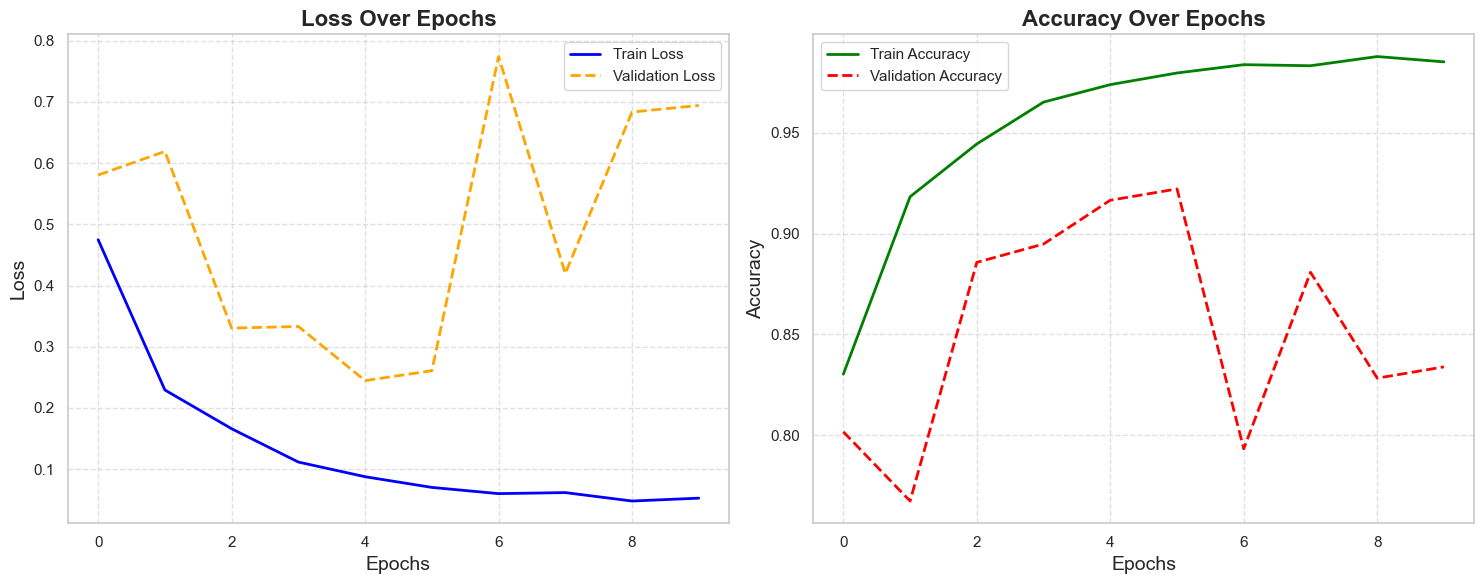

In [23]:
hist_ = pd.DataFrame(history.history)

# Determine accuracy column names correctly
if 'accuracy' in hist_.columns:
    train_acc_col, val_acc_col = 'accuracy', 'val_accuracy'
elif 'accuracy' in hist_.columns:
    train_acc_col, val_acc_col = 'accuracy', 'val_accuracy'
else:
    raise KeyError(f"Accuracy keys not found in history. Available keys: {list(hist_.columns)}")

sns.set(style="whitegrid")

plt.figure(figsize=(15, 6))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(hist_['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(hist_['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='dashed')
plt.title('Loss Over Epochs', fontsize=16, weight='bold')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(hist_[train_acc_col], label='Train Accuracy', color='green', linewidth=2)
plt.plot(hist_[val_acc_col], label='Validation Accuracy', color='red', linewidth=2, linestyle='dashed')
plt.title('Accuracy Over Epochs', fontsize=16, weight='bold')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [20]:
# Load the model
model_path = r"C:\Users\Nour Hesham\Downloads\model_classification.h5"
model = tf.keras.models.load_model(model_path)

In [96]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

c:\Users\Nour Hesham\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


45/45 ━━━━━━━━━━━━━━━━━━━━ 314s 7s/step - accuracy: 0.9376 - loss: 0.1721
Test Accuracy: 0.9375
Test Loss: 0.1898


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
    ]
)

In [59]:
history_finetune = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9891 - loss: 0.0525
Epoch 1: val_accuracy improved from -inf to 0.92922, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 2654s 7s/step - accuracy: 0.9891 - loss: 0.0525 - val_accuracy: 0.9292 - val_loss: 0.2486
Epoch 2/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9901 - loss: 0.0457
Epoch 2: val_accuracy did not improve from 0.92922
357/357 ━━━━━━━━━━━━━━━━━━━━ 2554s 7s/step - accuracy: 0.9901 - loss: 0.0457 - val_accuracy: 0.9285 - val_loss: 0.2527
Epoch 3/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9901 - loss: 0.0441
Epoch 3: val_accuracy improved from 0.92922 to 0.92992, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 2465s 7s/step - accuracy: 0.9901 - loss: 0.0441 - val_accuracy: 0.9299 - val_loss: 0.2553
Epoch 4/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9930 - loss: 0.0385
Epoch 4: val_accuracy improved from 0.92992 to 0.93132, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 2390s 7s/step - accuracy: 0.9930 - loss: 0.0385 - val_accuracy: 0.9313 - val_loss: 0.2576
Epoch 5/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9925 - loss: 0.0382
Epoch 5: val_accuracy did not improve from 0.93132
357/357 ━━━━━━━━━━━━━━━━━━━━ 2419s 7s/step - accuracy: 0.9925 - loss: 0.0382 - val_accuracy: 0.9306 - val_loss: 0.2609
Epoch 6/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9938 - loss: 0.0338
Epoch 6: val_accuracy did not improve from 0.93132
357/357 ━━━━━━━━━━━━━━━━━━━━ 2444s 7s/step - accuracy: 0.9938 - loss: 0.0338 - val_accuracy: 0.9306 - val_loss: 0.2628
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


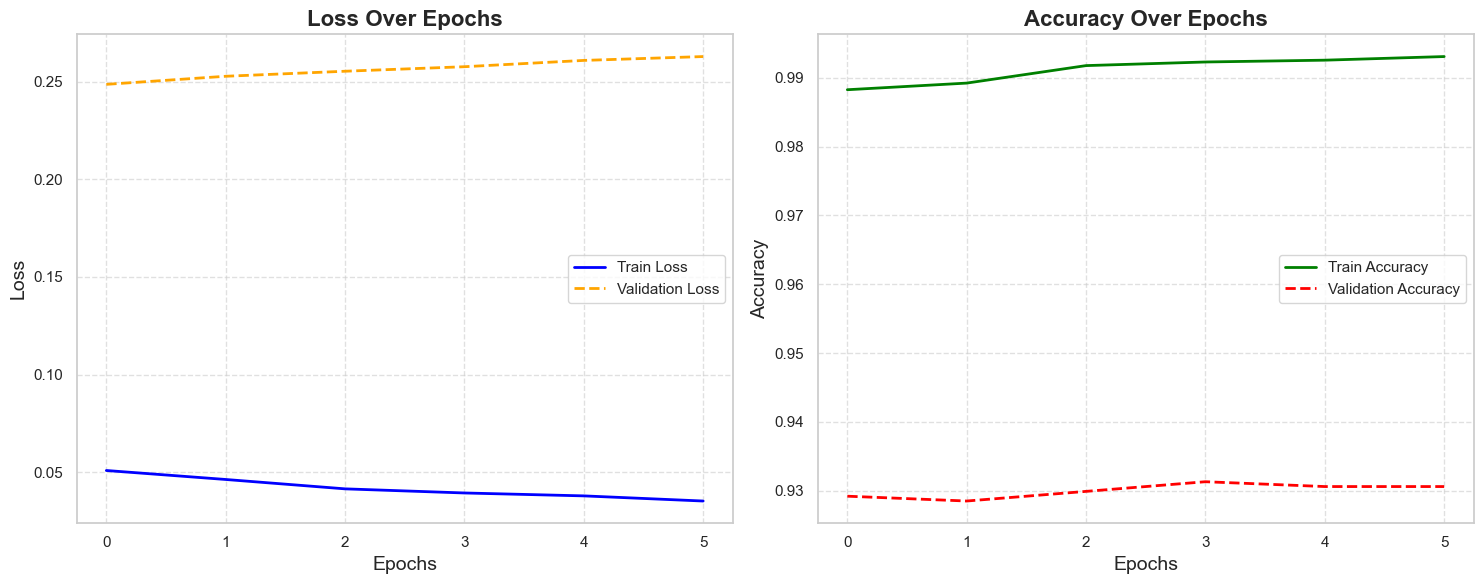

In [69]:
hist_ = pd.DataFrame(history_finetune.history)

# Determine accuracy column names correctly
if 'accuracy' in hist_.columns:
    train_acc_col, val_acc_col = 'accuracy', 'val_accuracy'
elif 'accuracy' in hist_.columns:
    train_acc_col, val_acc_col = 'accuracy', 'val_accuracy'
else:
    raise KeyError(f"Accuracy keys not found in history. Available keys: {list(hist_.columns)}")

sns.set(style="whitegrid")

plt.figure(figsize=(15, 6))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(hist_['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(hist_['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='dashed')
plt.title('Loss Over Epochs', fontsize=16, weight='bold')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(hist_[train_acc_col], label='Train Accuracy', color='green', linewidth=2)
plt.plot(hist_[val_acc_col], label='Validation Accuracy', color='red', linewidth=2, linestyle='dashed')
plt.title('Accuracy Over Epochs', fontsize=16, weight='bold')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [67]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 263s 6s/step - accuracy: 0.9321 - loss: 0.2340
Test Accuracy: 0.9306
Test Loss: 0.2473


In [ ]:
model_path = r"C:\Users\Nour Hesham\Downloads\AI-Disease-Classification\backend\model_ML\save_model\model_classification.h5"
model = tf.keras.models.load_model(model_path)

In [59]:
def apply_disease_specific_enhancement(image, disease_type):
    """Applies light disease-specific enhancement."""
    if disease_type == 'Edema':
        blurred = cv2.GaussianBlur(image, (3, 3), 0)
        return cv2.addWeighted(image, 1.2, blurred, -0.2, 0)

    elif disease_type == 'Lung_Opacity':
        return cv2.convertScaleAbs(image, alpha=1.1, beta=3)

    elif disease_type == 'Tuberculosis':
        kernel = np.array([[0, -1, 0], [-1, 5.5, -1], [0, -1, 0]])
        return cv2.filter2D(image, -1, kernel)

    elif disease_type == 'Corona_Virus_Disease':
        return cv2.bilateralFilter(image, d=7, sigmaColor=50, sigmaSpace=50)

    elif disease_type == 'Bacterial_Pneumonia':
        kernel = np.ones((2, 2), np.uint8)
        closed = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
        return cv2.convertScaleAbs(closed, alpha=1.05, beta=5)

    elif disease_type == 'Viral_Pneumonia':
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
        return cv2.filter2D(image, -1, kernel)

    # No enhancement for unknown/normal
    return image


def enhance_medical_image(image, disease_type=None, img_size=(224, 224)):
    """
    Enhances chest X-ray images with soft processing and disease-specific adjustment.

    Parameters:
    - image (numpy.ndarray): Input image (RGB or grayscale).
    - disease_type (str): Optional disease type to guide enhancement.
    - img_size (tuple): Target size (height, width).

    Returns:
    - numpy.ndarray: Enhanced image.
    """
    # Step 1: Convert to grayscale if image is RGB
    is_rgb = (len(image.shape) == 3 and image.shape[2] == 3)
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if is_rgb else image.copy()

    # Step 2: Resize image
    resized = cv2.resize(gray, img_size, interpolation=cv2.INTER_AREA).astype(np.uint8)

    # Step 3: Apply CLAHE (soft contrast enhancement)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(resized)

    # Step 4: Apply mild denoising
    denoised = cv2.fastNlMeansDenoising(contrast_enhanced, None, h=5, templateWindowSize=7, searchWindowSize=21)

    # Step 5: Apply disease-specific enhancement (if applicable)
    enhanced = apply_disease_specific_enhancement(denoised, disease_type)

    # Step 6: Normalize image to 0–255
    enhanced = cv2.normalize(enhanced, None, 0, 255, cv2.NORM_MINMAX)

    # Step 7: Return to RGB if original image was RGB
    if is_rgb:
        enhanced = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

    return enhanced


In [61]:
def preprocess_image(img):
    img = enhance_medical_image(img, disease_type=None, img_size=img_size) 
    img = img.astype(np.float32) / 255.0 
    return img

In [99]:
unfreeze_from = -50
for layer in model.layers[unfreeze_from:]:
    layer.trainable = True
for layer in model.layers[:unfreeze_from]:
    layer.trainable = False


In [100]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
    ]
)

In [52]:
# Data generators
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_image
)

ts_gen = ImageDataGenerator(
    preprocessing_function=preprocess_image
)

# Training generator
train_generator = train_gen.flow_from_dataframe(
    dataframe=train_df_new,
    x_col='image_path',  # Ensure this column contains valid image paths
    y_col='category_encoded',  # This should be either string or numeric
    target_size=img_size,
    batch_size=32,
    class_mode='sparse',  # Use 'sparse' if category_encoded is numeric
    color_mode='rgb',
    shuffle=True
)

# Validation generator
valid_generator = ts_gen.flow_from_dataframe(
    dataframe=valid_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    batch_size=32,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True
)

# Test generator
test_generator = ts_gen.flow_from_dataframe(
    dataframe=test_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    batch_size=32,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=False
)

Found 11272 validated image filenames belonging to 7 classes.
Found 1409 validated image filenames belonging to 7 classes.
Found 1409 validated image filenames belonging to 7 classes.


In [102]:
history_finetune = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

c:\Users\Nour Hesham\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9555 - loss: 0.1445
Epoch 1: val_accuracy improved from -inf to 0.97019, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


353/353 ━━━━━━━━━━━━━━━━━━━━ 3344s 9s/step - accuracy: 0.9555 - loss: 0.1445 - val_accuracy: 0.9702 - val_loss: 0.1101
Epoch 2/5
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9653 - loss: 0.1162
Epoch 2: val_accuracy improved from 0.97019 to 0.97303, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


353/353 ━━━━━━━━━━━━━━━━━━━━ 2608s 7s/step - accuracy: 0.9653 - loss: 0.1162 - val_accuracy: 0.9730 - val_loss: 0.1035
Epoch 3/5
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9651 - loss: 0.1108
Epoch 3: val_accuracy improved from 0.97303 to 0.97374, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


353/353 ━━━━━━━━━━━━━━━━━━━━ 2594s 7s/step - accuracy: 0.9651 - loss: 0.1108 - val_accuracy: 0.9737 - val_loss: 0.0999
Epoch 4/5
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9659 - loss: 0.1093
Epoch 4: val_accuracy did not improve from 0.97374
353/353 ━━━━━━━━━━━━━━━━━━━━ 2518s 7s/step - accuracy: 0.9659 - loss: 0.1093 - val_accuracy: 0.9723 - val_loss: 0.0966
Epoch 5/5
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9710 - loss: 0.1028
Epoch 5: val_accuracy improved from 0.97374 to 0.97516, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


353/353 ━━━━━━━━━━━━━━━━━━━━ 2518s 7s/step - accuracy: 0.9710 - loss: 0.1028 - val_accuracy: 0.9752 - val_loss: 0.0939
Restoring model weights from the end of the best epoch: 5.


In [16]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

c:\Users\Nour Hesham\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


45/45 ━━━━━━━━━━━━━━━━━━━━ 373s 8s/step - accuracy: 0.9746 - loss: 0.0961
Test Accuracy: 0.9723
Test Loss: 0.1060


In [15]:


def apply_disease_specific_enhancement(image, disease_type):
    # ... (دالتك الحالية بدون تغيير) ...
    # نسخ دالتك هنا
    if disease_type == 'Edema':
        blurred = cv2.GaussianBlur(image, (3, 3), 0)
        return cv2.addWeighted(image, 1.2, blurred, -0.2, 0)
    elif disease_type == 'Lung_Opacity':
        return cv2.convertScaleAbs(image, alpha=1.1, beta=3)
    elif disease_type == 'Tuberculosis':
        kernel = np.array([[0, -1, 0], [-1, 5.5, -1], [0, -1, 0]])
        return cv2.filter2D(image, -1, kernel)
    elif disease_type == 'Corona_Virus_Disease':
        return cv2.bilateralFilter(image, d=7, sigmaColor=50, sigmaSpace=50)
    elif disease_type == 'Bacterial_Pneumonia':
        kernel = np.ones((2, 2), np.uint8)
        closed = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
        return cv2.convertScaleAbs(closed, alpha=1.05, beta=5)
    elif disease_type == 'Viral_Pneumonia':
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
        return cv2.filter2D(image, -1, kernel)
    return image


def enhance_medical_image_for_dark(image, disease_type=None, img_size_param=(224, 224)): # تم تغيير الاسم قليلاً
    """
    Enhances chest X-ray images, with a focus on improving dark/low-contrast images.
    """
    is_rgb = (len(image.shape) == 3 and image.shape[2] == 3)
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if is_rgb else image.copy()

    resized = cv2.resize(gray, img_size_param, interpolation=cv2.INTER_AREA).astype(np.uint8)

    # --- تحسينات للصور الغامقة ---
    # 1. زيادة حدة CLAHE (زيادة clipLimit)
    clahe_stronger = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8)) # <--- زيادة clipLimit
    contrast_enhanced = clahe_stronger.apply(resized)

    # 2. (اختياري) تطبيق Gamma Correction لزيادة سطوع المناطق المظلمة
    # Gamma < 1 يزيد السطوع، Gamma > 1 يقلله. يجب أن تكون حذرًا هنا.
    # gamma = 0.8 # مثال، جرب قيمًا بين 0.7 و 0.9
    # invGamma = 1.0 / gamma
    # table = np.array([((i / 255.0) ** invGamma) * 255
    #                   for i in np.arange(0, 256)]).astype("uint8")
    # gamma_corrected = cv2.LUT(contrast_enhanced, table)
    # current_image = gamma_corrected # استخدم هذه إذا طبقت Gamma
    current_image = contrast_enhanced # استخدم هذه إذا لم تطبق Gamma

    # 3. (اختياري) موازنة হিস্টوجرام عامة بعد CLAHE إذا كانت الصور لا تزال مظلمة جدًا
    # equalized_hist = cv2.equalizeHist(current_image)
    # current_image = equalized_hist

    # --- نهاية تحسينات الصور الغامقة ---

    denoised = cv2.fastNlMeansDenoising(current_image, None, h=7, templateWindowSize=7, searchWindowSize=21) # يمكن زيادة h قليلاً

    # تطبيق التحسينات الخاصة بالمرض (إذا كانت لا تزال ذات صلة بعد التحسينات العامة)
    # أو يمكنك تبسيط هذا الجزء إذا كان التركيز فقط على الصور الغامقة
    enhanced_final = apply_disease_specific_enhancement(denoised, disease_type)

    enhanced_final = cv2.normalize(enhanced_final, None, 0, 255, cv2.NORM_MINMAX)

    if is_rgb:
        enhanced_final = cv2.cvtColor(enhanced_final, cv2.COLOR_GRAY2RGB)

    return enhanced_final

# دالة preprocess_image الجديدة التي تستدعي المعالجة المُحسّنة للصور الغامقة
# يجب أن يكون img_size مُعرفًا كمتغير عام في هذا الملف إذا لم يتم تمريره
# أو الأفضل تمريره كمعلمة
GLOBAL_IMG_SIZE_PREPROCESS = (224, 224) # مثال لمتغير عام

def preprocess_image_dark_enhanced(img, target_size=GLOBAL_IMG_SIZE_PREPROCESS): # جعل target_size معلمة
    """
    Preprocesses an image using the dark-enhancement pipeline.
    """
    if img is None: return None
    try:
        # استدعاء دالة التحسين الجديدة
        img_enhanced = enhance_medical_image_for_dark(img, disease_type=None, img_size_param=target_size)
        if img_enhanced is None: return None

        # تأكد من أن المخرج RGB إذا كان النموذج يتوقع ذلك
        if img_enhanced.ndim == 2: # إذا كانت رمادية
            img_enhanced_rgb = cv2.cvtColor(img_enhanced, cv2.COLOR_GRAY2RGB)
        elif img_enhanced.shape[-1] == 1: # رمادية بقناة واحدة
            img_enhanced_rgb = cv2.cvtColor(img_enhanced, cv2.COLOR_GRAY2RGB)
        elif img_enhanced.shape[-1] == 4: # RGBA
            img_enhanced_rgb = cv2.cvtColor(img_enhanced_rgb, cv2.COLOR_RGBA2RGB)
        else:
            img_enhanced_rgb = img_enhanced

        if img_enhanced_rgb.shape[-1] != 3:
            print(f"تحذير: الصورة بعد التحسين لا تحتوي على 3 قنوات: {img_enhanced_rgb.shape}")
            return None

        img_normalized = img_enhanced_rgb.astype(np.float32) / 255.0
        return img_normalized
    except Exception as e:
        print(f"خطأ في preprocess_image_dark_enhanced: {e}")
        return None

In [20]:
unfreeze_from = -50
for layer in model.layers[unfreeze_from:]:
    layer.trainable = True
for layer in model.layers[:unfreeze_from]:
    layer.trainable = False


In [21]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
    ]
)

In [49]:
# Data generators
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_image
)

ts_gen = ImageDataGenerator(
    preprocessing_function=preprocess_image
)

# Training generator
train_generator = train_gen.flow_from_dataframe(
    dataframe=train_df_new,
    x_col='image_path',  # Ensure this column contains valid image paths
    y_col='category_encoded',  # This should be either string or numeric
    target_size=img_size,
    batch_size=32,
    class_mode='sparse',  # Use 'sparse' if category_encoded is numeric
    color_mode='rgb',
    shuffle=True
)

# Validation generator
valid_generator = ts_gen.flow_from_dataframe(
    dataframe=valid_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    batch_size=32,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True
)

# Test generator
test_generator = ts_gen.flow_from_dataframe(
    dataframe=test_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    batch_size=32,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=False
)

Found 11272 validated image filenames belonging to 7 classes.
Found 1409 validated image filenames belonging to 7 classes.
Found 1409 validated image filenames belonging to 7 classes.


In [23]:
history_finetune = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

c:\Users\Nour Hesham\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9687 - loss: 0.1012
Epoch 1: val_accuracy improved from -inf to 0.97516, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


353/353 ━━━━━━━━━━━━━━━━━━━━ 2707s 8s/step - accuracy: 0.9687 - loss: 0.1012 - val_accuracy: 0.9752 - val_loss: 0.0935
Epoch 2/5
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9708 - loss: 0.0970
Epoch 2: val_accuracy did not improve from 0.97516
353/353 ━━━━━━━━━━━━━━━━━━━━ 2468s 7s/step - accuracy: 0.9708 - loss: 0.0970 - val_accuracy: 0.9730 - val_loss: 0.0925
Epoch 3/5
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9739 - loss: 0.0873
Epoch 3: val_accuracy did not improve from 0.97516
353/353 ━━━━━━━━━━━━━━━━━━━━ 2900s 8s/step - accuracy: 0.9739 - loss: 0.0873 - val_accuracy: 0.9752 - val_loss: 0.0901
Epoch 4/5
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9740 - loss: 0.0901
Epoch 4: val_accuracy improved from 0.97516 to 0.97587, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


353/353 ━━━━━━━━━━━━━━━━━━━━ 3026s 9s/step - accuracy: 0.9741 - loss: 0.0900 - val_accuracy: 0.9759 - val_loss: 0.0905
Epoch 5/5
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9797 - loss: 0.0752
Epoch 5: val_accuracy improved from 0.97587 to 0.97729, saving model to C:\Users\Nour Hesham\Downloads\model_classification.h5


353/353 ━━━━━━━━━━━━━━━━━━━━ 2767s 8s/step - accuracy: 0.9797 - loss: 0.0752 - val_accuracy: 0.9773 - val_loss: 0.0900
Restoring model weights from the end of the best epoch: 5.


In [54]:
# === 3. إنشاء نموذج Autoencoder ===
def build_autoencoder(input_shape):
    input_img = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(input_img, decoded)
    encoder = models.Model(input_img, encoded)

    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder((224,224,3))

In [55]:
# 4. Generator لـ autoencoder (المدخل = المخرج)
def autoencoder_generator(gen):
    while True:
        x, _ = next(gen)
        yield x, x

In [56]:
# 5. تدريب autoencoder
autoencoder.fit(
    autoencoder_generator(train_generator),
    steps_per_epoch=len(train_generator),
    epochs=8,
    validation_data=autoencoder_generator(valid_generator),
    validation_steps=len(valid_generator)
)

Epoch 1/8
353/353 [==============================] - 1922s 5s/step - loss: 0.0075 - val_loss: 0.0025
Epoch 2/8
353/353 [==============================] - 1877s 5s/step - loss: 0.0021 - val_loss: 0.0019
Epoch 3/8
353/353 [==============================] - 1850s 5s/step - loss: 0.0018 - val_loss: 0.0017
Epoch 4/8
353/353 [==============================] - 1854s 5s/step - loss: 0.0017 - val_loss: 0.0017
Epoch 5/8
353/353 [==============================] - 1801s 5s/step - loss: 0.0016 - val_loss: 0.0015
Epoch 6/8
353/353 [==============================] - 2031s 6s/step - loss: 0.0015 - val_loss: 0.0014
Epoch 7/8
353/353 [==============================] - 1919s 5s/step - loss: 0.0015 - val_loss: 0.0015
Epoch 8/8
353/353 [==============================] - 1776s 5s/step - loss: 0.0014 - val_loss: 0.0014


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# === 6. دالة لحساب خطأ الإعادة لكل صورة ===
def reconstruction_errors(autoencoder, generator):
    errors = []
    images = []
    labels = []
    for _ in range(len(generator)):
        x_batch, y_batch = next(generator)
        x_decoded = autoencoder.predict(x_batch)
        for i in range(len(x_batch)):
            error = mean_squared_error(x_batch[i].flatten(), x_decoded[i].flatten())
            errors.append(error)
            images.append(x_batch[i])
            labels.append(y_batch[i])
    return np.array(errors), np.array(images), np.array(labels)

# === 7. حساب خطأ الإعادة على بيانات validation لتحديد threshold ===
recon_errors_val, _, _ = reconstruction_errors(autoencoder, valid_generator)
threshold = np.percentile(recon_errors_val, 95)  # أعلى 5% = Unknown

print(f"Reconstruction error threshold: {threshold:.4f}")


1/1 [==============================] - 0s 367ms/step
Reconstruction error threshold: 0.0032


In [58]:
# حفظ النموذج الكامل (autoencoder)
autoencoder.save('model_ML/save_model/autoencoder_model.h5')

# حفظ جزء الـ encoder فقط
encoder.save('model_ML/save_model/encoder_model.h5')


c:\Users\Nour Hesham\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [61]:
known_images = []
unknown_images = []

for i in range(len(test_generator)):
    img, _ = next(test_generator)
    reconstructed = autoencoder.predict(img)
    error = mean_squared_error(img[0].flatten(), reconstructed[0].flatten())
    
    if error <= threshold:
        known_images.append(img[0])
    else:
        unknown_images.append(img[0])

print(f"📁 Known images: {len(known_images)}")
print(f"❓ Unknown images: {len(unknown_images)}")


1/1 [==============================] - 2s 2s/step
📁 Known images: 42
❓ Unknown images: 3


In [103]:
num_batches = 600
all_predicted_labels = []
all_true_labels = []

for i, (images_batch, labels_batch) in enumerate(test_generator):
    if i >= num_batches:
        break
    
    # Print shapes to verify correctness
    print(f"Batch {i+1}: images_batch.shape={images_batch.shape}, labels_batch.shape={labels_batch.shape}")

    # Get model predictions
    batch_predictions = model.predict(images_batch, verbose=0)
    
    # Extract predicted class labels
    predicted_labels = batch_predictions.argmax(axis=1)

    # Ensure labels_batch is correctly formatted before using np.argmax()
    if labels_batch.ndim == 1:  # Already categorical labels
        true_labels = labels_batch
    else:  # One-hot encoded labels
        true_labels = labels_batch.argmax(axis=1)
    
    all_predicted_labels.extend(predicted_labels)
    all_true_labels.extend(true_labels)

# Extract class names from test_generator
class_names = list(test_generator.class_indices.keys())

# Generate classification report
report = classification_report(all_true_labels, all_predicted_labels, target_names=class_names)

# Print the classification report
print(report)

Batch 1: images_batch.shape=(32, 224, 224, 3), labels_batch.shape=(32,)
Batch 2: images_batch.shape=(32, 224, 224, 3), labels_batch.shape=(32,)
Batch 3: images_batch.shape=(32, 224, 224, 3), labels_batch.shape=(32,)
Batch 4: images_batch.shape=(32, 224, 224, 3), labels_batch.shape=(32,)
Batch 5: images_batch.shape=(32, 224, 224, 3), labels_batch.shape=(32,)
Batch 6: images_batch.shape=(32, 224, 224, 3), labels_batch.shape=(32,)
Batch 7: images_batch.shape=(32, 224, 224, 3), labels_batch.shape=(32,)
Batch 8: images_batch.shape=(32, 224, 224, 3), labels_batch.shape=(32,)
Batch 9: images_batch.shape=(32, 224, 224, 3), labels_batch.shape=(32,)
Batch 10: images_batch.shape=(32, 224, 224, 3), labels_batch.shape=(32,)
Batch 11: images_batch.shape=(32, 224, 224, 3), labels_batch.shape=(32,)
Batch 12: images_batch.shape=(32, 224, 224, 3), labels_batch.shape=(32,)
Batch 13: images_batch.shape=(32, 224, 224, 3), labels_batch.shape=(32,)
Batch 14: images_batch.shape=(32, 224, 224, 3), labels_batch

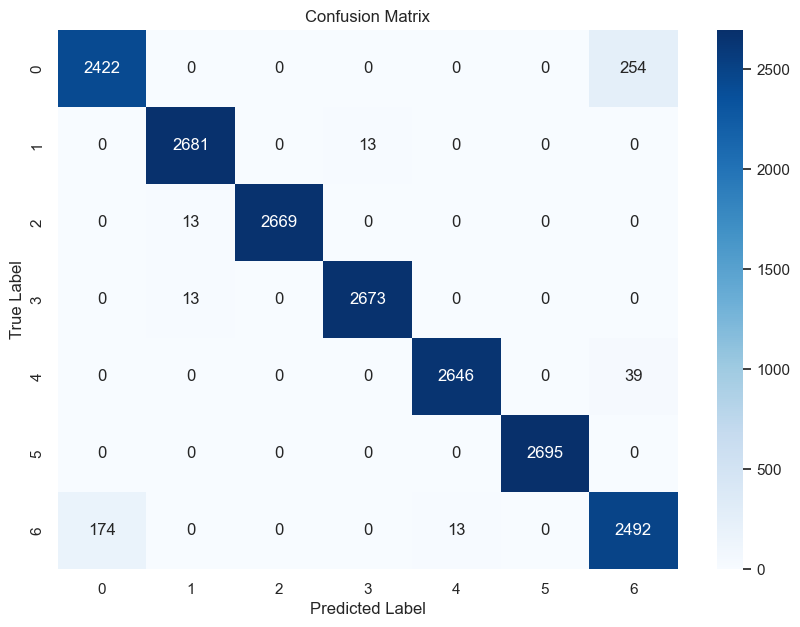

In [104]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
conf_matrix = confusion_matrix(all_true_labels, all_predicted_labels)

# Plot the confusion matrix using Seaborn heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [18]:
class_names = {
    0: "Bacterial Pneumonia",
    1: "Corona Virus Disease",
    2: "Edema",
    3: "Lung Opacity",
    4: "Normal",
    5: "Tuberculosis",
    6: "Viral Pneumonia"
}

## Test from test_ds

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


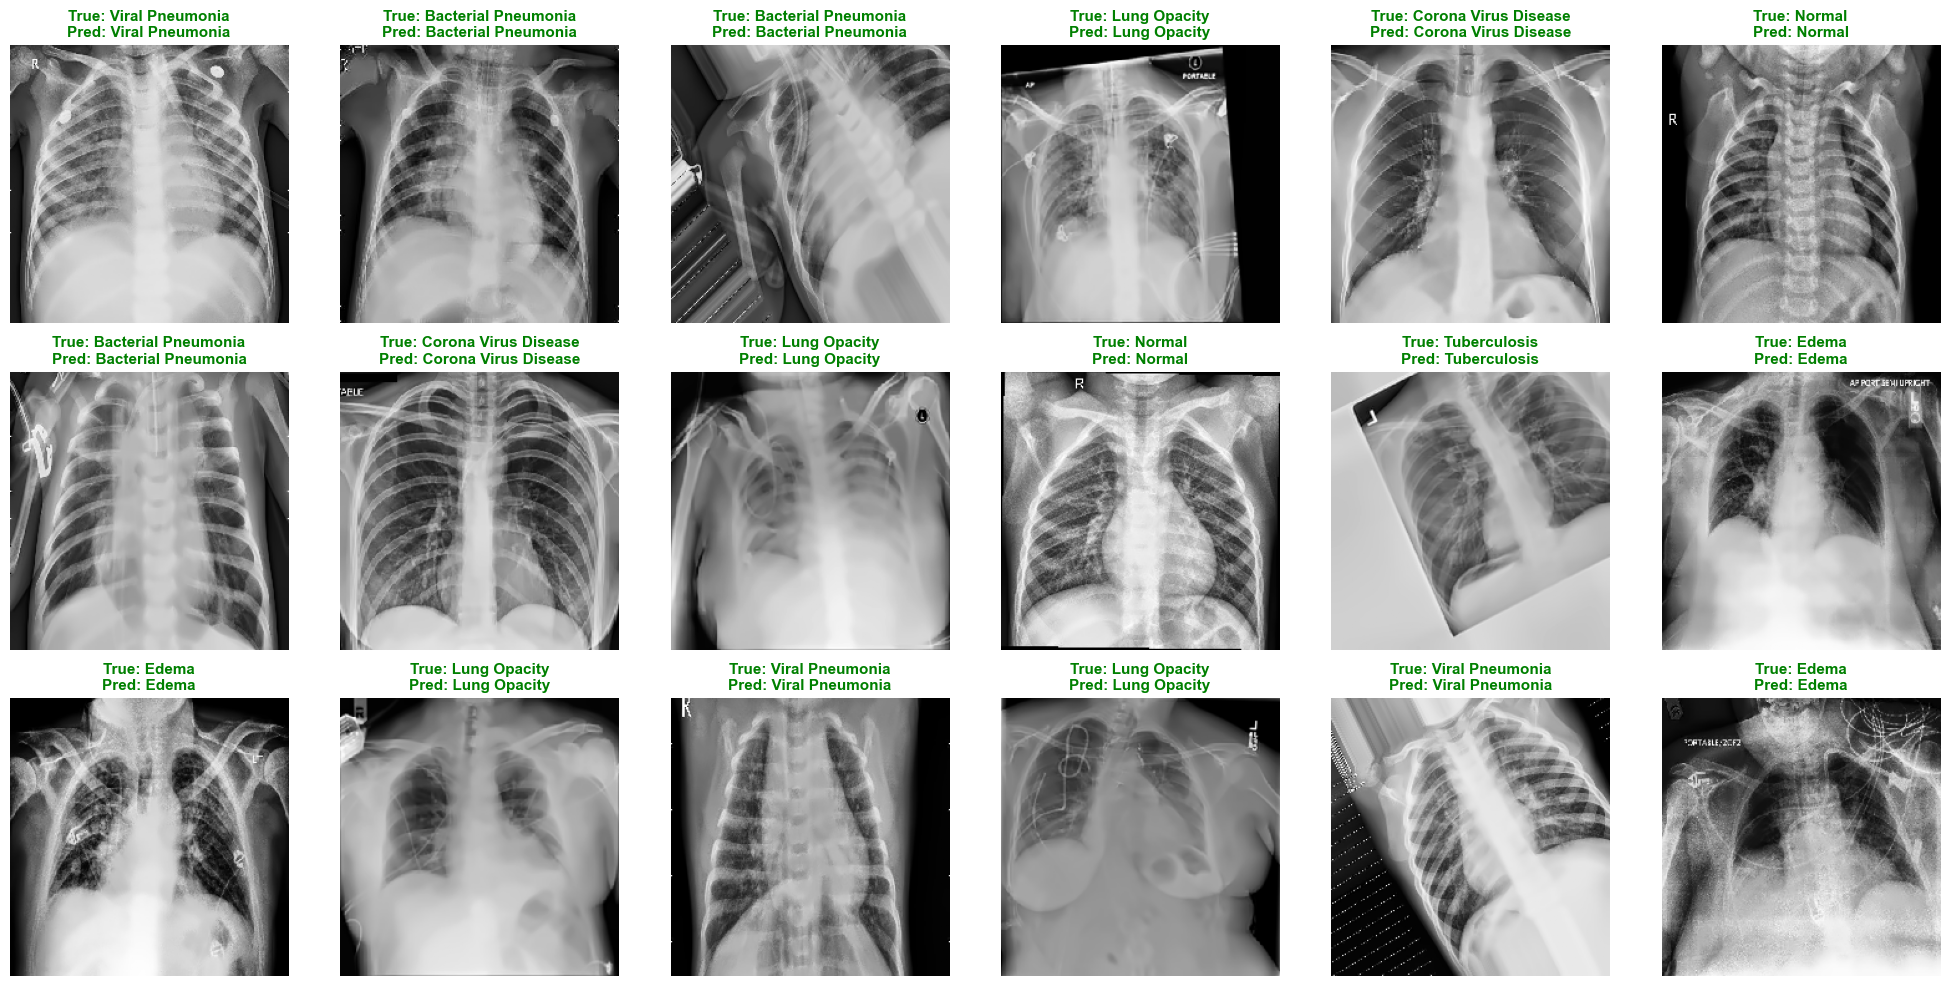

In [106]:
# Get a batch of images and labels from the generator
x_batch, y_batch = next(test_generator)  

# Convert one-hot encoded labels to class indices if necessary
if y_batch.ndim > 1 and y_batch.shape[1] > 1:  
    y_batch = np.argmax(y_batch, axis=1)  

# Select 18 random images
num_images = 18
indices = np.random.choice(len(x_batch), num_images, replace=False)
selected_images = x_batch[indices]
true_labels = y_batch[indices]

# Make predictions using the trained model
predictions = model.predict(selected_images)
predicted_labels = np.argmax(predictions, axis=1)

# Set figure size and background style
plt.figure(figsize=(20, 10))
sns.set_style("whitegrid")  # Clean grid style

# Display images with true and predicted labels
for i in range(num_images):
    plt.subplot(3, 6, i + 1)

    # Detect if the images are grayscale
    is_grayscale = selected_images[i].shape[-1] == 1
    cmap = 'gray' if is_grayscale else None

    plt.imshow(selected_images[i], cmap=cmap)
    
    # Determine title color (Green if correct, Red if wrong)
    title_color = "green" if true_labels[i] == predicted_labels[i] else "red"
    
    plt.title(f"True: {class_names[int(true_labels[i])]}\nPred: {class_names[predicted_labels[i]]}", 
              fontsize=11, color=title_color, fontweight='bold')

    plt.axis('off')

plt.tight_layout()
plt.show()


## Test img from another source

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


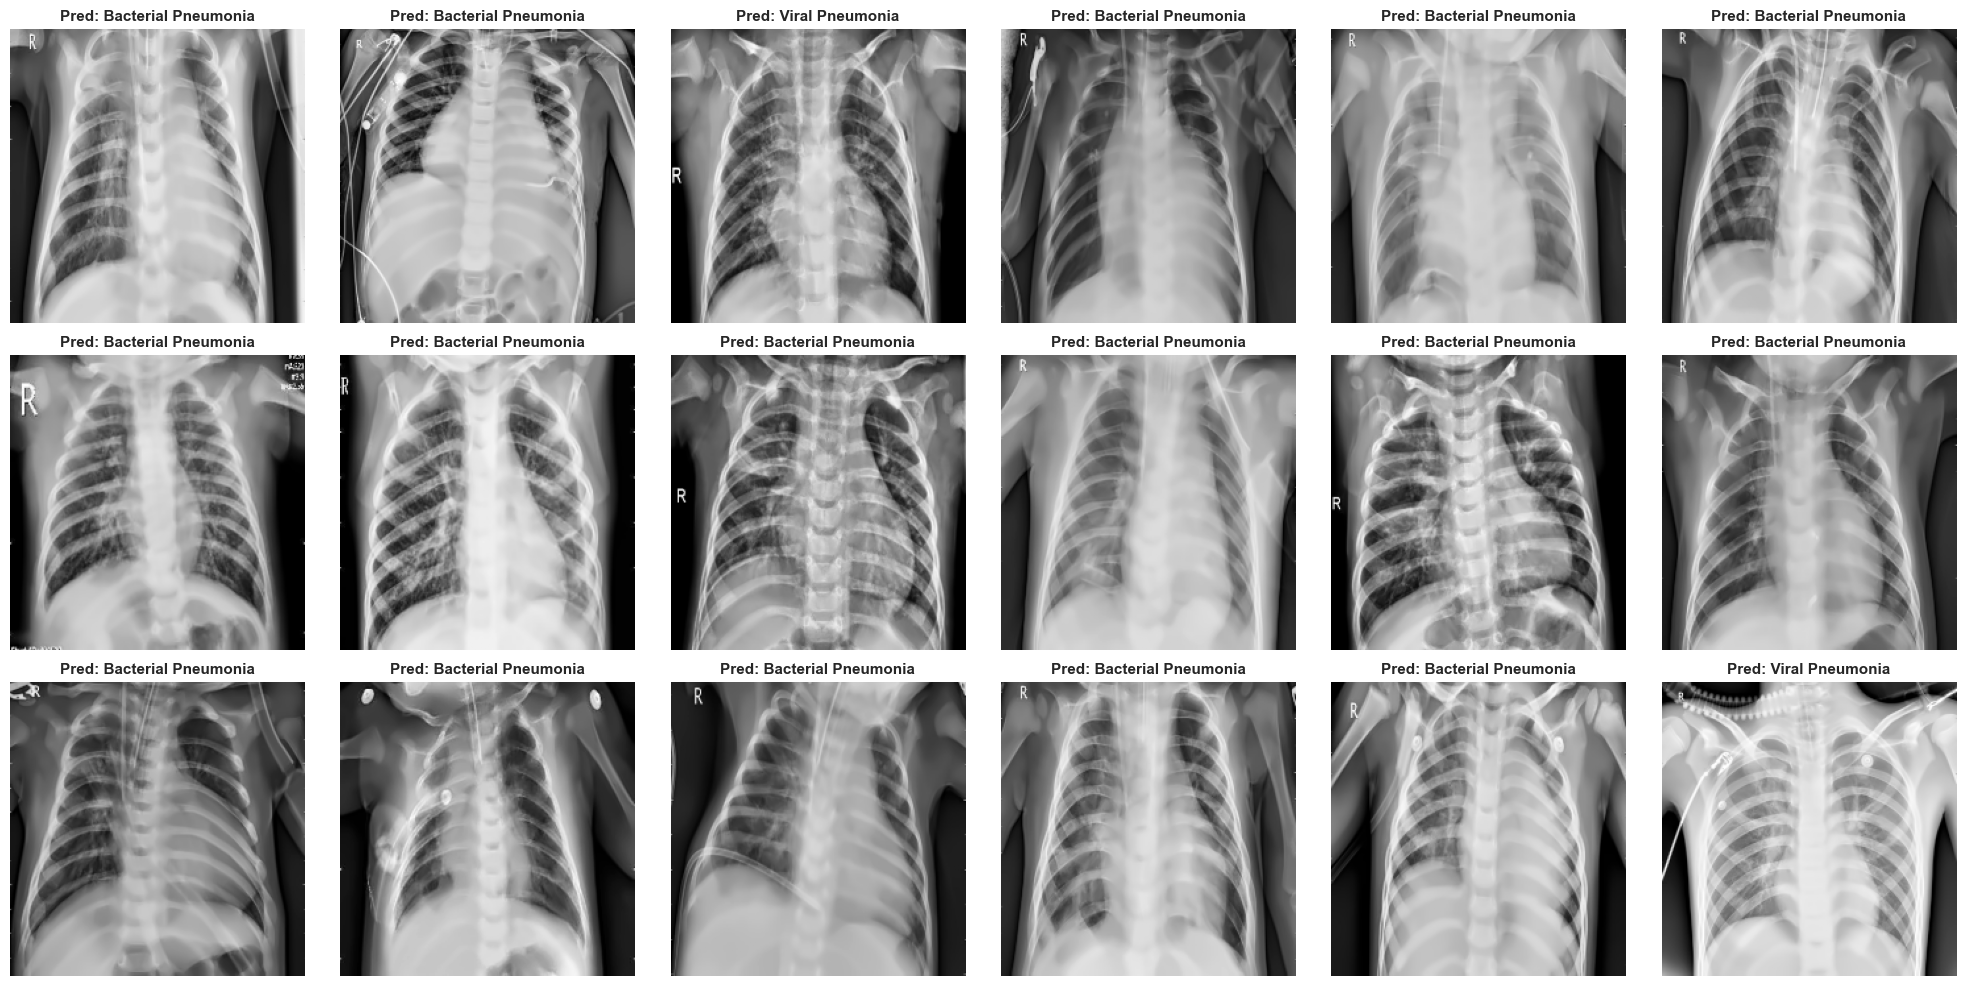

In [116]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Define the path to the image folder
folder_path = r"C:\Users\Nour Hesham\Downloads\archive (1)\Pneumonia-Bacterial"

# Collect all image file paths
image_files = [os.path.join(folder_path, img) for img in os.listdir(folder_path) 
               if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Select a random sample of images
num_images = 18
selected_files = np.random.choice(image_files, num_images, replace=False)


# Load and preprocess selected images
selected_images = []
for file_path in selected_files:
    # Read image using OpenCV and convert to RGB
    img = cv2.imread(file_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Apply preprocessing/enhancement
    enhanced_img = preprocess_image(img)  
    
    selected_images.append(enhanced_img)

# Convert the list to a NumPy array
selected_images = np.array(selected_images)

# Run predictions using your trained model (make sure model is loaded)
predictions = model.predict(selected_images)
predicted_labels = np.argmax(predictions, axis=1)

# Display the results
plt.figure(figsize=(20, 10))
sns.set_style("whitegrid")

for i in range(num_images):
    plt.subplot(3, 6, i + 1)
    plt.imshow(selected_images[i])
    plt.title(f"Pred: {class_names[predicted_labels[i]]}", fontsize=11, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


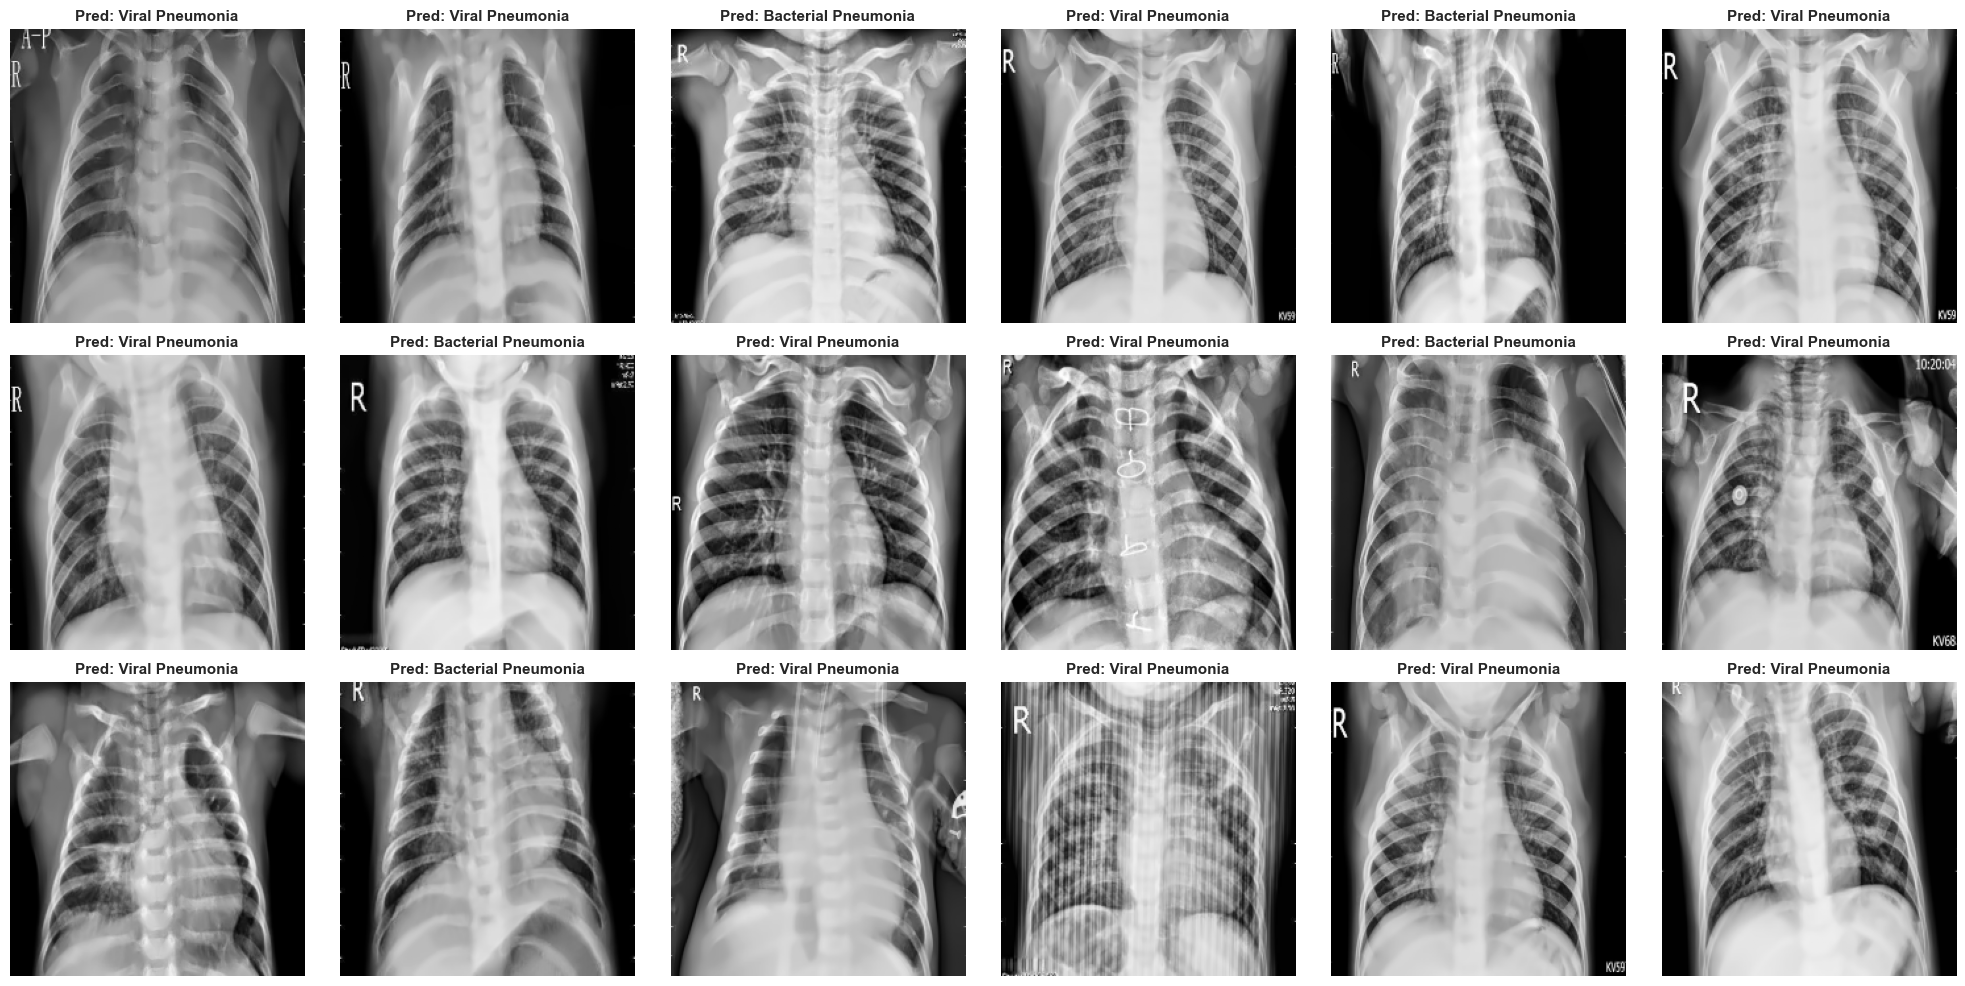

In [19]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Define the path to the image folder
folder_path = r"C:\Users\Nour Hesham\Downloads\archive (1)\Pneumonia-Viral"

# Collect all image file paths
image_files = [os.path.join(folder_path, img) for img in os.listdir(folder_path) 
               if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Select a random sample of images
num_images = 18
selected_files = np.random.choice(image_files, num_images, replace=False)


# Load and preprocess selected images
selected_images = []
for file_path in selected_files:
    # Read image using OpenCV and convert to RGB
    img = cv2.imread(file_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Apply preprocessing/enhancement
    enhanced_img = preprocess_image(img)  
    
    selected_images.append(enhanced_img)

# Convert the list to a NumPy array
selected_images = np.array(selected_images)

# Run predictions using your trained model (make sure model is loaded)
predictions = model.predict(selected_images)
predicted_labels = np.argmax(predictions, axis=1)

# Display the results
plt.figure(figsize=(20, 10))
sns.set_style("whitegrid")

for i in range(num_images):
    plt.subplot(3, 6, i + 1)
    plt.imshow(selected_images[i])
    plt.title(f"Pred: {class_names[predicted_labels[i]]}", fontsize=11, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


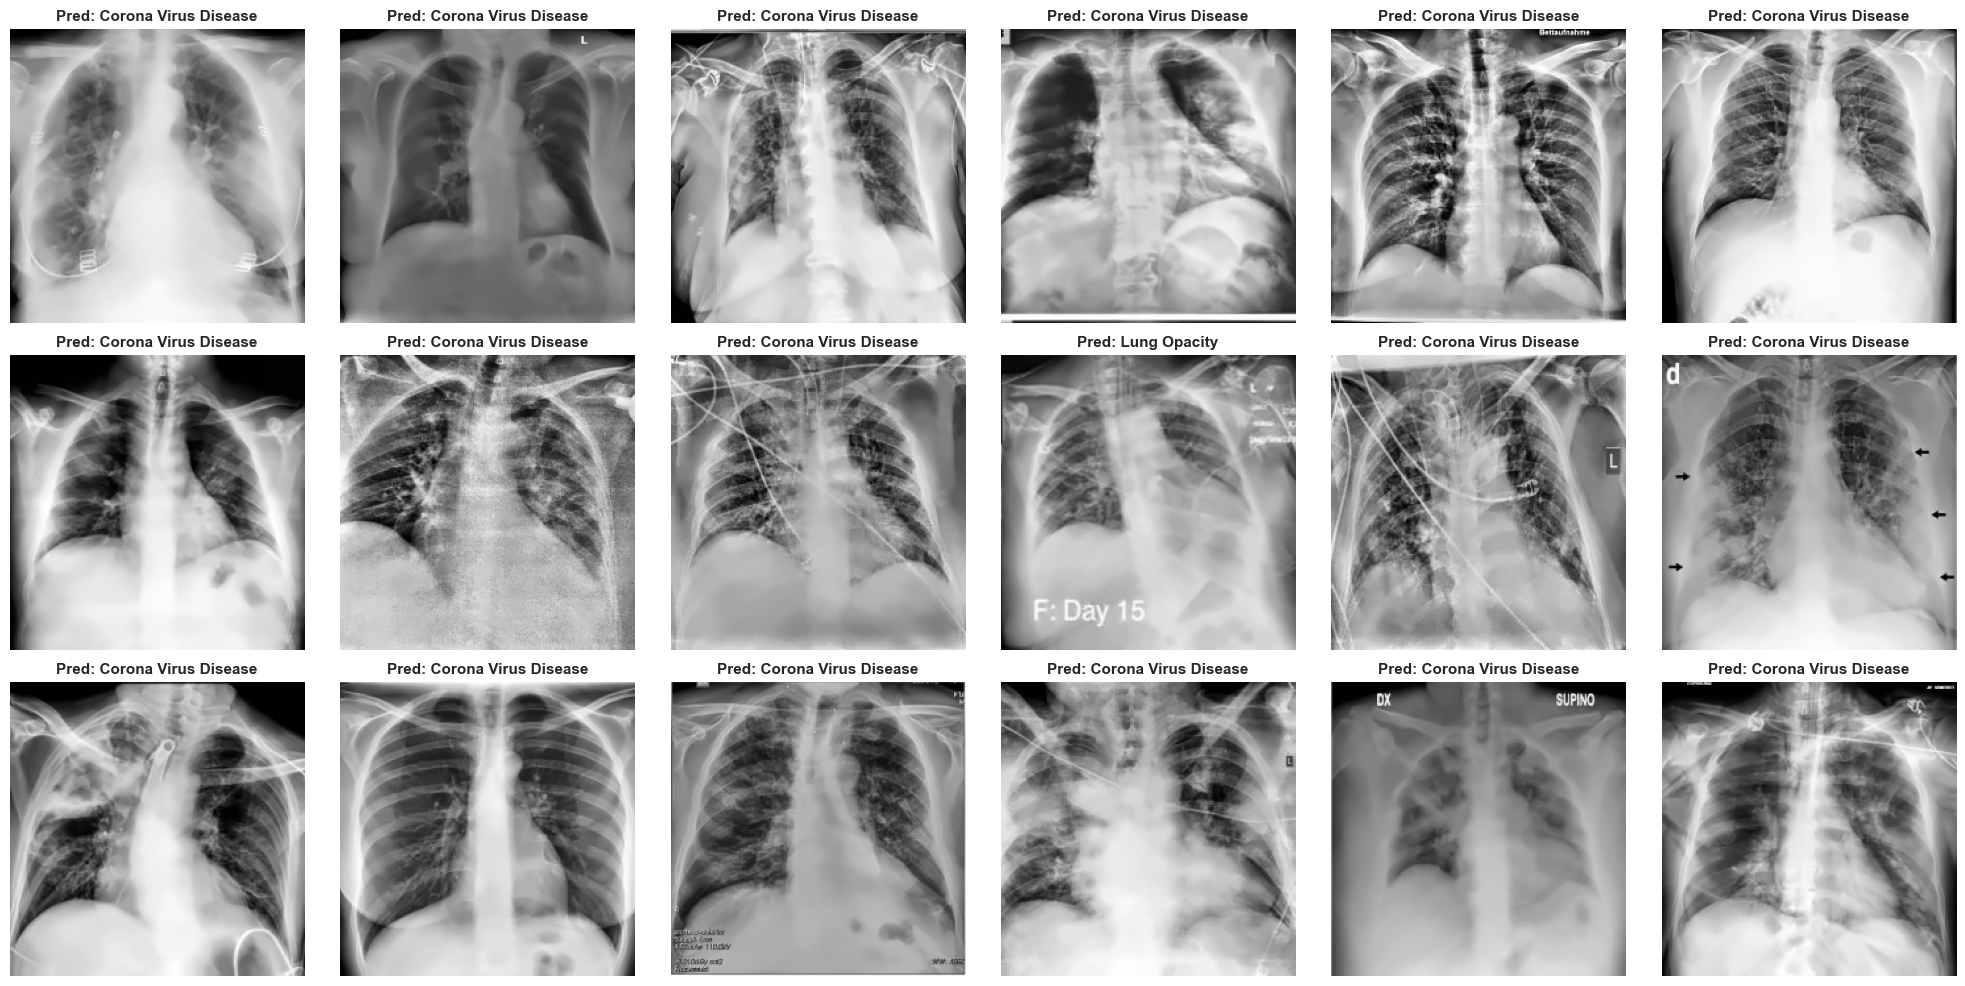

In [117]:
# Define the folder containing images
folder_path = r"C:\Users\Nour Hesham\Downloads\archive (1)\COVID-19"

# Collect all image file paths
image_files = [os.path.join(folder_path, img) for img in os.listdir(folder_path) 
               if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Select a random sample of images
num_images = 18
selected_files = np.random.choice(image_files, num_images, replace=False)


# Load and preprocess selected images
selected_images = []
for file_path in selected_files:
    # Read image using OpenCV and convert to RGB
    img = cv2.imread(file_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Apply preprocessing/enhancement
    enhanced_img = preprocess_image(img)  
    
    selected_images.append(enhanced_img)

# Convert the list to a NumPy array
selected_images = np.array(selected_images)

# Run predictions using your trained model (make sure model is loaded)
predictions = model.predict(selected_images)
predicted_labels = np.argmax(predictions, axis=1)

# Display the results
plt.figure(figsize=(20, 10))
sns.set_style("whitegrid")

for i in range(num_images):
    plt.subplot(3, 6, i + 1)
    plt.imshow(selected_images[i])
    plt.title(f"Pred: {class_names[predicted_labels[i]]}", fontsize=11, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()


Error loading image from : Invalid URL '': No scheme supplied. Perhaps you meant https://?
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step


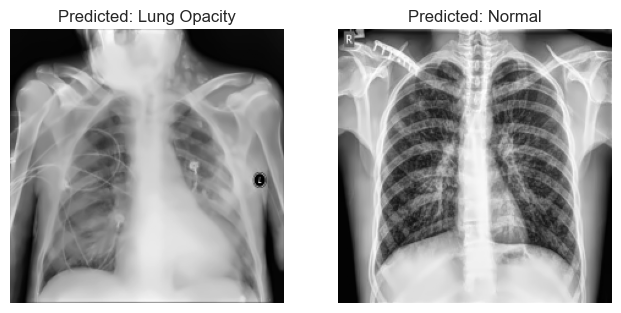

In [121]:
import requests
from io import BytesIO
from PIL import Image

# List of image URLs
image_urls = [
    "",  # Tuberculosis
    "https://th.bing.com/th/id/R.f60a753763be025175c6f3db5ab523e8?rik=7qeEV%2b74%2fde0FQ&pid=ImgRaw&r=0",  # Lung Opacity
    "https://th.bing.com/th/id/OIP.5-YNnF3PvmgIEg5FqpRzQwHaGR?rs=1&pid=ImgDetMain"  # Normal
]


# Load and preprocess images
selected_images = []

for i, url in enumerate(image_urls):
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()  # Check if request was successful
        image = Image.open(BytesIO(response.content))
        
        # Convert to OpenCV format
        image = np.array(image)

        # Ensure all images are RGB (convert grayscale to RGB)
        if len(image.shape) == 2:  # If grayscale, convert to RGB
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        elif image.shape[-1] == 4:  # If RGBA, convert to RGB
            image = cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)

        # Preprocess the image based on disease type
        disease_type = disease_types[i]
        image = preprocess_image(image)
        selected_images.append(image)

    except requests.exceptions.RequestException as e:
        print(f"Error loading image from {url}: {e}")

# Convert to NumPy array
selected_images = np.array(selected_images)

# Predict if images were successfully loaded
if selected_images.shape[0] > 0:
    predictions = model.predict(selected_images)
    predicted_labels = np.argmax(predictions, axis=1)

    # Display images with predicted labels
    plt.figure(figsize=(12, 6))
    for i in range(len(selected_images)):
        plt.subplot(1, 3, i + 1)
        plt.imshow(selected_images[i])
        plt.title(f"Predicted: {class_names[predicted_labels[i]]}")
        plt.axis("off")

    plt.show()
else:
    print("No images were processed.")
